Name: Samin Thapa

ID: 2408644

# Task 1: Data Preparation

In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.preprocessing import OneHotEncoder

Training set: (17002, 28, 28, 1), Labels: (17002, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


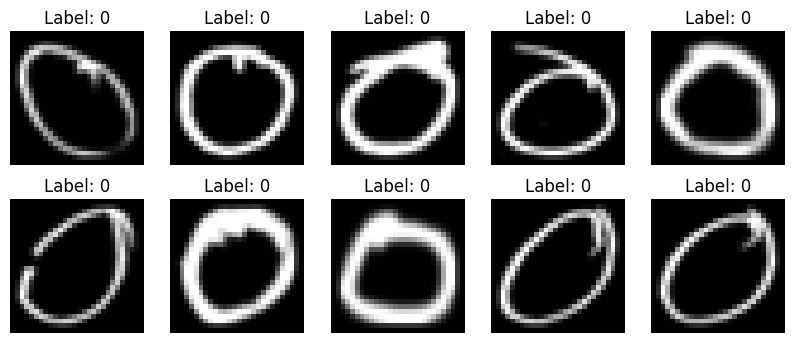

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Colab Notebooks/AI/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/AI/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # Sorted class names
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize
            img = np.array(img) / 255.0  # Normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

# Task 2: Build the FCN Model

In [3]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

In [4]:
model.compile(
  optimizer = "adam",
  loss = "categorical_crossentropy",
  metrics=["accuracy", "precision"]
)


# Task 4: Train the Model

In [5]:
batch_size = 128
epochs = 2000

# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.15,
  callbacks=callbacks,
)



Epoch 1/2000
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4647 - loss: 1.6538 - precision: 0.9699 - val_accuracy: 0.0913 - val_loss: 5.4549 - val_precision: 0.0000e+00
Epoch 2/2000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8377 - loss: 0.5346 - precision: 0.9461 - val_accuracy: 0.2599 - val_loss: 5.9308 - val_precision: 0.3323
Epoch 3/2000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9197 - loss: 0.2824 - precision: 0.9431 - val_accuracy: 0.3046 - val_loss: 6.0904 - val_precision: 0.3679
Epoch 4/2000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9447 - loss: 0.1928 - precision: 0.9562 - val_accuracy: 0.2944 - val_loss: 6.3573 - val_precision: 0.3371
Epoch 5/2000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9588 - loss: 0.1454 - precision: 0.9652 - val_accuracy: 0.3128 - val_loss: 6.5272 - val_precision: 0.3557


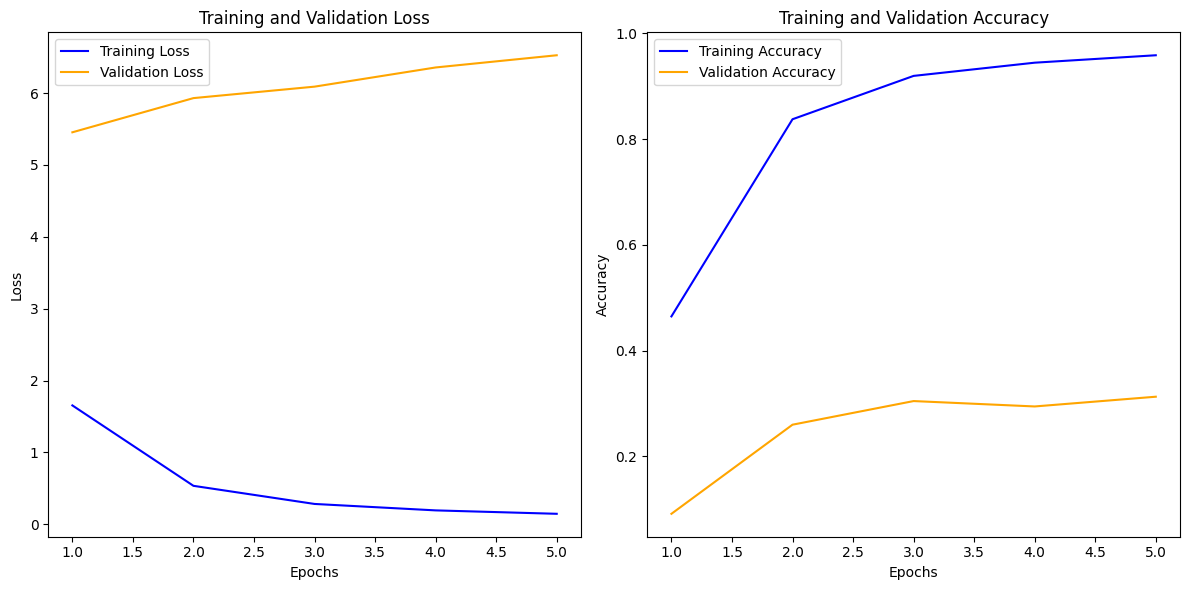

In [6]:
import matplotlib.pyplot as plt

# Extracting training and validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training Loss", color="blue")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label="Training Accuracy", color="blue")
plt.plot(range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Task 5: Evaluate the Model

In [7]:
test_loss, test_acc, test_precision = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")


94/94 - 0s - 2ms/step - accuracy: 0.8630 - loss: 1.0970 - precision: 0.8894
Test accuracy: 0.8630


# Task 6: Save and Load the Model


In [8]:
# saving the model
model.save("devnagari_fully_connected_model.h5")

# loading the saved model
loaded_model = tf.keras.models.load_model("devnagari_fully_connected_model.h5")


In [9]:
# re evaluating the model on the test set
test_loss, test_acc, test_precision = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 1s - 7ms/step - accuracy: 0.8630 - loss: 1.0970 - precision_1: 0.8894
Test accuracy: 0.8630


# Task 7: Predictions

In [10]:
# Make predictions on test data
predictions = loaded_model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Display first 5 predictions
print("Sample Predictions")
for i in range(5):
    print(f"Image {i+1}: Predicted = {predicted_labels[i]}, True = {true_labels[i]}, "
          f"{'Correct' if predicted_labels[i] == true_labels[i] else 'Wrong'}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Sample Predictions
Image 1: Predicted = 0, True = 0, Correct
Image 2: Predicted = 0, True = 0, Correct
Image 3: Predicted = 0, True = 0, Correct
Image 4: Predicted = 0, True = 0, Correct
Image 5: Predicted = 0, True = 0, Correct


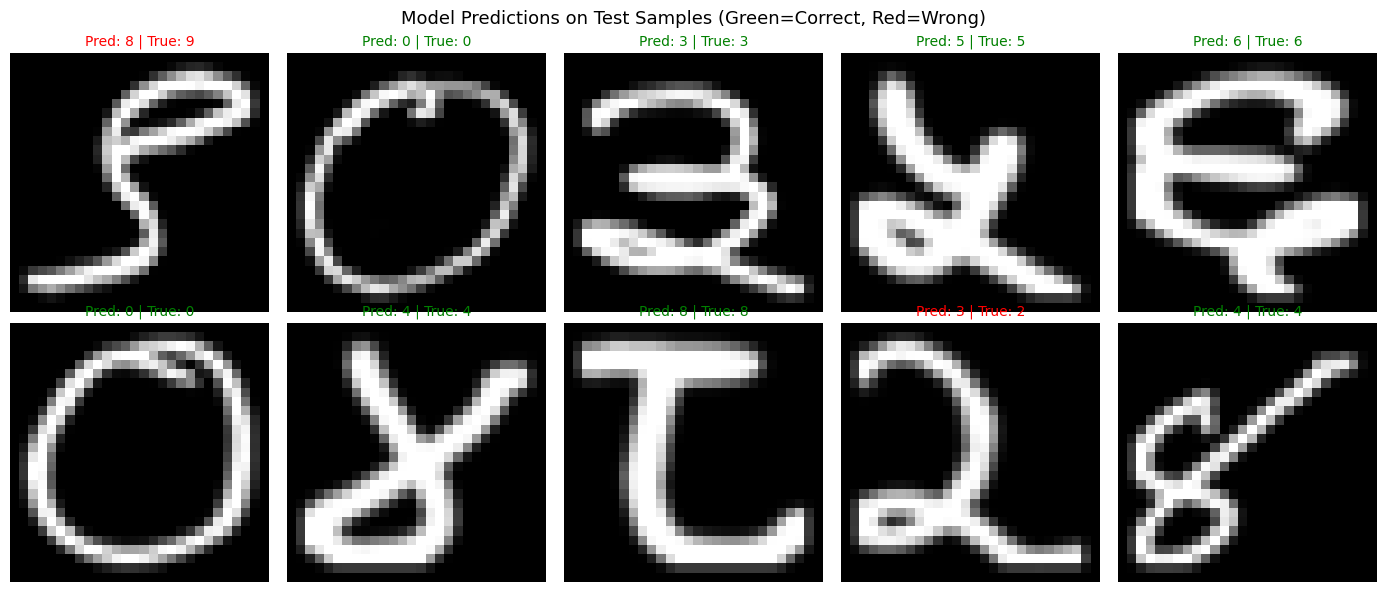

In [11]:
# Visualize predictions on sample test images
plt.figure(figsize=(14, 6))

# Pick 10 random test samples
np.random.seed(47)
sample_indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')

    pred = predicted_labels[idx]
    true = true_labels[idx]
    color = 'green' if pred == true else 'red'

    plt.title(f"Pred: {pred} | True: {true}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Model Predictions on Test Samples (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()